::: {.callout-note appearance="minimal" icon=false}
Language: **Python** (Jupyter notebook) - [R version](r.qmd)
:::

Ported from
[`03_mcmc_basics.ipynb`](https://github.com/USACE-RMC/Numerics-Python-Examples/blob/main/notebooks/03_mcmc_basics.ipynb)
in the USACE-RMC Numerics-Python-Examples repository (0BSD licensed). The upstream
notebook drives the C# `Numerics.dll` through pythonnet; this version uses
`bestfitpy`, whose compiled core is a validated C++ port of the same library. The
seeded data draws below reproduce the upstream values exactly. The posterior numbers
are close to the upstream's but deliberately not identical, because this port builds
its priors differently (explained below). The R version of this example uses the
same core and prints the same numbers.

One honest caveat up front: the upstream's first example estimates the mean alone,
with the standard deviation fixed at 15 and a hand-picked Uniform(50, 150) prior
passed through a custom log-likelihood delegate. `bestfitpy.mcmc_sample()` always
fits every parameter of a family under uniform priors derived from the family's
parameter constraints, so that fixed-sigma example is not expressible with the
public API. This port teaches the same concepts on the upstream's second example,
where both the mean and the standard deviation are unknown.

## What you'll learn

- What MCMC is and when to use it.
- How the Random Walk Metropolis-Hastings (RWMH) sampler works.
- How to read a trace plot and spot a run that has not converged.
- What warmup (burn-in) and thinning do.
- How to summarize a posterior and check acceptance rates and R-hat.

## What is MCMC

Markov Chain Monte Carlo draws samples from a posterior distribution that is known
only up to a normalizing constant. By Bayes' theorem, the posterior is proportional
to the product of the prior and the likelihood:

$$
\pi(\theta \mid y) \propto \pi(\theta) \cdot L(y \mid \theta)
$$

It is common to work with the logarithm of this product, which is how the library
works internally:

$$
\log \pi(\theta \mid y) = \log \pi(\theta) + \log L(y \mid \theta) + \text{const}
$$

MCMC is useful when:

- You want to quantify uncertainty in parameters, not just point estimates.
- You have prior knowledge to incorporate.
- You need full posterior distributions.
- Standard optimization methods are insufficient.

The library ports all of the upstream samplers; `mcmc_sample()` accepts any of them
by name:

| Sampler | Full name | Best for |
|---------|-----------|----------|
| RWMH | Random Walk Metropolis-Hastings | General purpose, small dimensions |
| ARWMH | Adaptive RWMH | Medium dimensions (2-20) |
| DEMCz | Differential Evolution MCMC | High dimensions, multimodal |
| DEMCzs | DE-MCMC with snooker update | Very high dimensions |
| HMC | Hamiltonian Monte Carlo | Smooth posteriors |
| NUTS | No-U-Turn Sampler | General smooth posteriors |
| SNIS | Self-normalized importance sampling | Cheap approximate posteriors |

This example uses RWMH, the simplest and most robust baseline. At each iteration
it proposes a new state from a symmetric normal distribution centered at the
current state, $\theta^* \sim \mathcal{N}(\theta, \Sigma)$, and accepts it with
probability

$$
\alpha = \min\left(1, \frac{\pi(\theta^*)}{\pi(\theta)}\right),
$$

computed in log space as $\log \alpha = \log \pi(\theta^*) - \log \pi(\theta)$.
Proposals that fall outside the prior bounds are rejected without evaluating the
likelihood. Theory gives target acceptance rates for RWMH of about 44% for one
parameter, falling toward 23.4% in high dimensions (Roberts, Gelman, and Gilks,
1997); we will check ours against that below.

## Setup

The upstream setup loads the CoreCLR runtime, resolves the DLL, and builds .NET
`List` and `Array` objects. None of that exists here; plain NumPy arrays work
everywhere.

In [1]:
import bestfitpy as bf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Earth-tone palette used throughout, one color per chain
pal = ["#6b7f3f", "#b06a3b", "#5b7a8c", "#8c8c7a"]
print("Setup complete")

Setup complete


## Step 1: Generate synthetic data

We draw 50 observations from a Normal(100, 15) with seed 42, exactly the upstream's
`Normal(100, 15).GenerateRandomValues(50, 42)`. The port keeps the C# Mersenne
Twister bit-exact, so these are the same 50 numbers the upstream notebook sees:
the sample mean prints 96.40 and the population standard deviation prints 17.13,
matching the upstream output digit for digit.

Generated 50 observations
Sample mean: 96.40
Sample std: 17.13


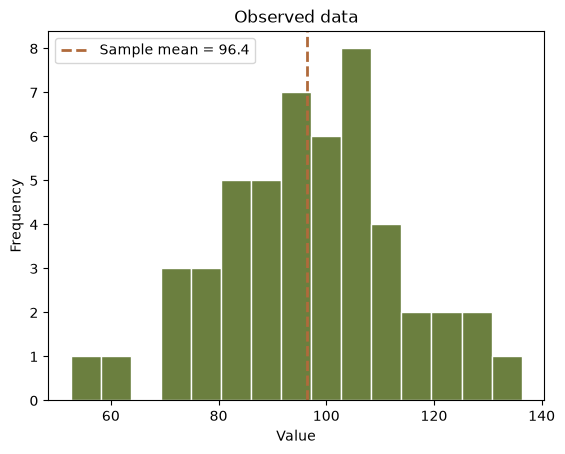

In [2]:
true_mu, true_sigma = 100, 15
data = np.asarray(bf.Distribution("Normal", [true_mu, true_sigma]).random(50, seed=42))

print(f"Generated {len(data)} observations")
print(f"Sample mean: {np.mean(data):.2f}")
print(f"Sample std: {np.std(data):.2f}")

plt.hist(data, bins=15, color="#6b7f3f", edgecolor="white")
plt.axvline(np.mean(data), color="#b06a3b", linestyle="--", linewidth=2,
            label=f"Sample mean = {np.mean(data):.1f}")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Observed data")
plt.legend()
plt.show()

## Step 2: Priors and likelihood

The upstream builds a .NET `List` of prior distributions (Uniform(50, 150) for the
mean, Uniform(1, 50) for the standard deviation) and wraps a Python function as a
`LogLikelihood` delegate. Here `mcmc_sample()` assembles both pieces for you: the
log-likelihood is the family's own, evaluated in the compiled core, and the priors
are uniforms spanning the family's parameter constraints (the C#
`GetParameterConstraints` bounds, which scale with the data). For this sample they
work out to mu ~ Uniform(-1000, 1000) and sigma ~ Uniform(~0, 1000). Both prior
sets are effectively flat over the region where the likelihood has any mass, so the
posteriors come out nearly the same, but the numbers cannot match the upstream's
bit for bit.

## Step 3: A first run, badly initialized

By default the sampler runs 4 chains initialized at the maximum a posteriori (MAP)
estimate. To see why convergence checking matters, we first do the opposite:
initialize each chain at a random draw from the (very wide) priors and run only
1,000 iterations.

A trace plot shows a parameter's sampled value at each recorded iteration, one line
per chain. A healthy, well-mixed chain looks like a fluffy caterpillar: random
scribble centered on the posterior mean, with no visible trends and all chains
overlapping. Chains that drift, or that disagree with each other, have not
converged.

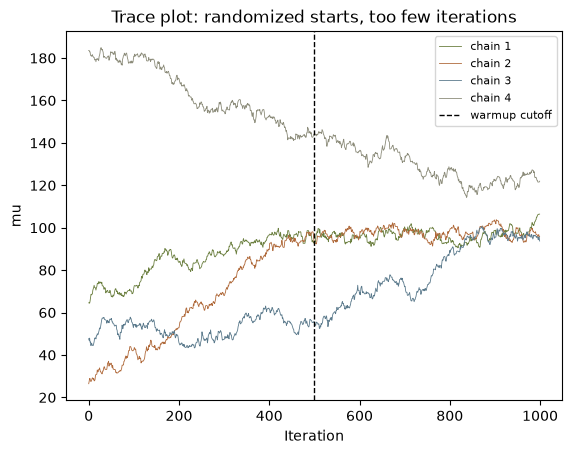

R-hat: [2.641 1.976]


In [3]:
bad = bf.mcmc_sample(data, "Normal", sampler="RWMH",
                     iterations=1000, warmup=500, thinning=1,
                     seed=12345, initialize="Randomize")

for i, chain in enumerate(bad["chains"]):
    plt.plot(chain[:, 0], linewidth=0.6, color=pal[i], label=f"chain {i + 1}")
plt.axvline(500, color="black", linestyle="--", linewidth=1, label="warmup cutoff")
plt.xlabel("Iteration")
plt.ylabel("mu")
plt.title("Trace plot: randomized starts, too few iterations")
plt.legend(loc="upper right", fontsize=8)
plt.show()

print("R-hat:", np.round(bad["rhat"], 3))

The chains start scattered across the prior and spend most of the run wandering
toward the posterior. The Gelman-Rubin statistic (R-hat) compares within-chain and
between-chain variance and should be very close to 1 at convergence; values well
above 1, like these, flag a run whose chains are still exploring. The fix is
cheap: better initialization and more iterations.

## Step 4: A proper run

Now the default MAP initialization and 3,000 iterations per chain, with the first
1,500 treated as warmup. The chains in the result include the warmup segment,
which is what makes plots like this possible; R-hat is computed from the
post-warmup portion only.

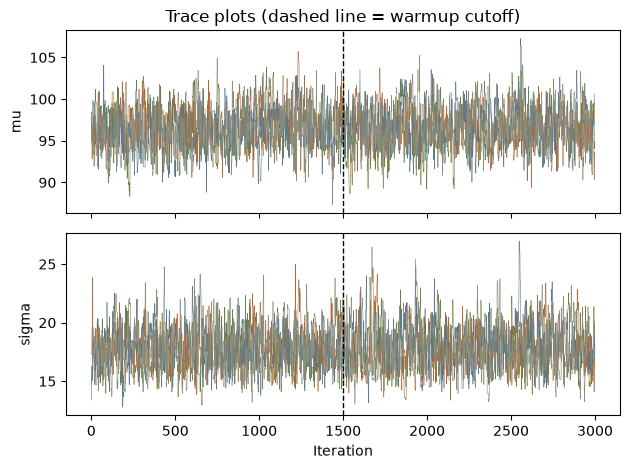

R-hat: [1.005 1.003]


In [4]:
fit = bf.mcmc_sample(data, "Normal", sampler="RWMH",
                     iterations=3000, warmup=1500, thinning=1, seed=12345)
warmup = 1500

fig, axes = plt.subplots(2, 1, sharex=True)
for p, ax in enumerate(axes):
    for i, chain in enumerate(fit["chains"]):
        ax.plot(chain[:, p], linewidth=0.4, color=pal[i])
    ax.axvline(warmup, color="black", linestyle="--", linewidth=1)
    ax.set_ylabel(["mu", "sigma"][p])
axes[0].set_title("Trace plots (dashed line = warmup cutoff)")
axes[1].set_xlabel("Iteration")
plt.tight_layout()
plt.show()

print("R-hat:", np.round(fit["rhat"], 3))

Both parameters now show the fluffy caterpillar: four overlapping chains, no
trends, and R-hat within a hair of 1.

## Step 5: Posterior summaries

The result carries per-parameter posterior summaries. Following the C# design,
these are computed from a dedicated posterior sample of about 10,000 draws that
the sampler records after the main iterations, so they do not depend on exactly
where you cut the warmup. The credible interval is the central 90% (5th to 95th
percentile). Recall the true values are mu = 100 and sigma = 15, and the data
summaries are 96.40 and 17.31 (sample standard deviation).

In [5]:
summary = pd.DataFrame({
    "parameter": fit["parameters"],
    "true": [true_mu, true_sigma],
    "map": fit["map"],
    "post_mean": fit["posterior_mean"],
    "post_sd": fit["posterior_sd"],
    "median": fit["posterior_median"],
    "pct_5": fit["posterior_lower_ci"],
    "pct_95": fit["posterior_upper_ci"],
    "rhat": fit["rhat"],
    "ess": fit["ess"],
})
print(summary.round(4).to_string(index=False))

print("\nAcceptance rates by chain:", np.round(fit["acceptance_rates"], 3))

parameter  true     map  post_mean  post_sd  median   pct_5   pct_95   rhat       ess
        µ   100 96.3987    96.4027   2.4468 96.4842 92.3519 100.2315 1.0052 1482.4061
        σ    15 17.1323    17.7938   1.8559 17.6358 15.0499  21.1403 1.0031 1065.8017

Acceptance rates by chain: [0.441 0.43  0.441 0.435]


The posterior mean of mu sits on the sample mean, and the 90% credible interval
comfortably covers the true value of 100. The posterior for sigma centers near the
sample standard deviation of 17.3 rather than the true 15: with 50 observations
this particular seed simply drew a wide sample, and the upstream notebook sees the
identical effect with its own priors (its sigma interval is [15.02, 21.02]; ours is
[15.05, 21.14]). The data, not the method, set that limit.

The acceptance rates land right around 0.44. For a two-parameter RWMH that is
squarely in the healthy range between the one-dimensional optimum (44%) and the
high-dimensional limit (23.4%). Very low rates mean the proposals are too
aggressive and almost always rejected; very high rates mean timid proposals and
slow exploration.

The marginal posteriors and the joint posterior, from the pooled post-warmup
draws:

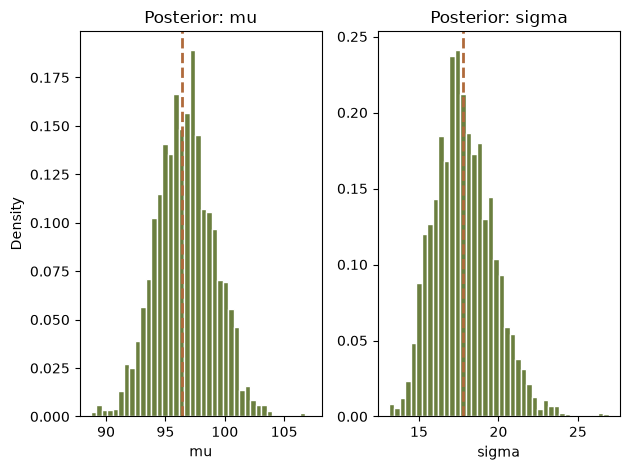

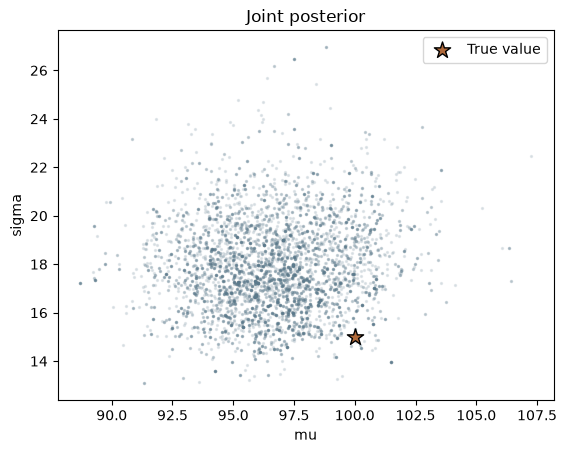

In [6]:
post = np.vstack([chain[warmup:] for chain in fit["chains"]])

fig, axes = plt.subplots(1, 2)
for p, ax in enumerate(axes):
    ax.hist(post[:, p], bins=40, density=True, color="#6b7f3f", edgecolor="white")
    ax.axvline(fit["posterior_mean"][p], color="#b06a3b", linestyle="--", linewidth=2)
    ax.set_xlabel(["mu", "sigma"][p])
axes[0].set_ylabel("Density")
axes[0].set_title("Posterior: mu")
axes[1].set_title("Posterior: sigma")
plt.tight_layout()
plt.show()

plt.scatter(post[:, 0], post[:, 1], s=2, alpha=0.15, color="#5b7a8c")
plt.scatter([true_mu], [true_sigma], s=150, marker="*", color="#b06a3b",
            edgecolor="black", zorder=5, label="True value")
plt.xlabel("mu")
plt.ylabel("sigma")
plt.title("Joint posterior")
plt.legend()
plt.show()

## Understanding warmup and thinning

**Warmup (burn-in).** The first stretch of every chain is influenced by its
arbitrary starting point, as the randomized run above made obvious. Those samples
are misleading and should be discarded. Rules of thumb from the upstream notebook:
RWMH wants 2,000-5,000 warmup iterations on hard problems, gradient samplers
(HMC/NUTS) closer to 1,000-2,000, and warmup of about half the iterations is a
reasonable default. This port enforces the C# constraint that warmup cannot exceed
half the iterations. Note the division of labor in the results: `chains` keeps the
warmup segment so you can plot it, R-hat drops it, and the posterior summaries come
from the separate post-run sample described above.

**Thinning.** Successive MCMC samples are autocorrelated. Thinning records only
every nth state: each row of a chain is the state after `thinning` internal steps,
and the default interval in this library is 20, matching C#. We set `thinning=1`
in this example precisely so the raw autocorrelation is visible below. Thinning
reduces autocorrelation in what you store, but it does not add information; running
longer is always at least as good. Keep the interval at or below the
autocorrelation length.

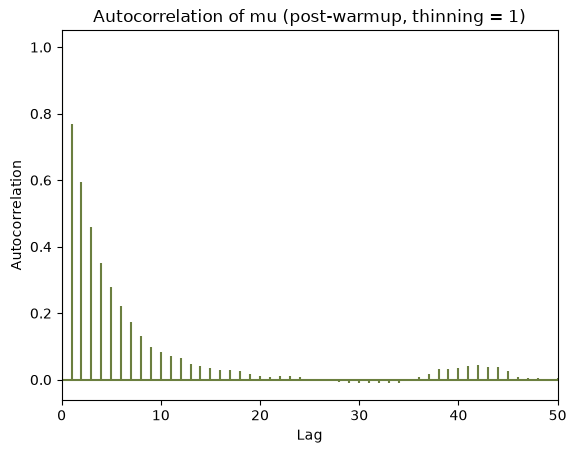

In [7]:
mu_post = post[:, 0]
plt.acorr(mu_post - mu_post.mean(), maxlags=50, color="#6b7f3f")
plt.xlim(0, 50)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of mu (post-warmup, thinning = 1)")
plt.show()

The autocorrelation decays within a few dozen lags, which is typical of a healthy
random-walk sampler. The effective sample size in the summary table (about 1,500
for mu out of 10,000 posterior draws) tells the same story: RWMH explores by
diffusion, so its draws are far from independent, and gradient samplers would score
much higher here.

## Summary

In this notebook you:

- Built a Bayesian model for Normal data with unknown mean and standard deviation.
- Ran RWMH through `mcmc_sample()`, which supplies constraint-based uniform priors
  and the family's own log-likelihood.
- Diagnosed a bad run and a good one with trace plots and R-hat.
- Read posterior summaries, credible intervals, acceptance rates, and ESS.

Key takeaway: MCMC gives full uncertainty quantification for parameters, not only
point estimates.

## Reproduction check

The seeded data draw is bit-exact against the upstream C# stream. The posterior
cannot be compared bit for bit: the upstream uses hand-picked Uniform(50, 150) and
Uniform(1, 50) priors through a custom likelihood delegate, while `mcmc_sample()`
uses the family's constraint-based uniform priors, so the samplers consume
different random streams. Those rows are checked statistically. The final rows
assert cross-language identity: the R twin asserts the very same literals, because
both packages run the same compiled core with the same seed.

| Quantity | Upstream C# | This port | Status |
|----------|------------:|----------:|--------|
| Seeded sample mean, `GenerateRandomValues(50, 42)` | 96.40 | 96.40 | exact |
| Seeded sample std (population) | 17.13 | 17.13 | exact |
| Posterior mean of mu | 96.427 | 96.403 | statistical (priors differ) |
| 90% CI for mu covers true mu = 100 | [92.22, 100.54] | [92.35, 100.23] | statistical |
| 90% CI for sigma covers sample sd 17.31 | [15.02, 21.02] | [15.05, 21.14] | statistical |
| RWMH acceptance rate near 0.44 | 0.43 | 0.43-0.44 | statistical |
| First seeded data value | n/a | 95.20221411105254 | exact (Python == R) |
| Posterior means (mu, sigma) | n/a | shared literals | exact (Python == R) |

The cell below fails the notebook if any check drifts.

In [8]:
# Upstream: 03_mcmc_basics.ipynb, cell 5 output (seeded data),
# cell 19 output (two-parameter posterior table), cell 21 output (acceptance rate).

# Exact tier: the seeded data draw reproduces the C# Mersenne Twister stream.
assert round(float(np.mean(data)), 2) == 96.40
assert round(float(np.std(data)), 2) == 17.13

# Statistical tier: constraint-based priors differ from the upstream's hand-picked
# ones, so we assert the inference, not the draws.
assert abs(fit["posterior_mean"][0] - np.mean(data)) < 1.0
assert fit["posterior_lower_ci"][0] <= true_mu <= fit["posterior_upper_ci"][0]
assert fit["posterior_lower_ci"][1] <= np.std(data, ddof=1) <= fit["posterior_upper_ci"][1]
assert np.all(fit["rhat"] < 1.05)
assert np.all((fit["acceptance_rates"] > 0.2) & (fit["acceptance_rates"] < 0.6))
assert bad["rhat"].max() > 1.5  # the badly initialized run is flagged

# Exact tier, cross-language: the R twin asserts these same literals.
assert data[0] == 95.20221411105254
assert fit["posterior_mean"][0] == 96.40267301325859
assert fit["posterior_mean"][1] == 17.793754146622998
assert fit["acceptance_rates"][0] == 0.4410909090909091
print("All reproduction checks passed.")

All reproduction checks passed.
